# Does Google Trends Predict Stock Market Movements?

## Introduction

For this project we wanted to work on something personally relevant to us. 
Having invested for a while, we've always wondered whether investor attention, 
measured through Google search interest, can tell us about how stocks move.

Hence, our research question is: does Google Trends search interest predict or follow market 
movements across four different sectors, and can it be used to predict returns?

The four assets we chose are:
- NVDA (Nvidia) — tech
- RTX (Raytheon) — defence  
- XOM (ExxonMobil) — energy
- IGLN — gold ETF

These are all stocks I tend to have positions in, which made the analysis and results more interesting to interpret.

The project combines three data sources: Yahoo Finance for price data, Google 
Trends for search interest, and NewsAPI with FinBERT for sentiment analysis.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from pytrends.request import TrendReq
import plotly.graph_objects as go
ASSETS = ['IGLN', 'NVDA', 'RTX', 'XOM']

RETURN_COLS = {
    'NVDA': 'NVDA_return',
    'RTX': 'RTX_return',
    'XOM': 'XOM_return',
    'IGLN': 'IGLN.L_return'
}

positions = [(1,1),(1,2),(2,1),(2,2)]

In [2]:
import yfinance as yf
import pandas as pd
import os

os.makedirs('data', exist_ok=True)

TICKERS = ['NVDA', 'RTX', 'XOM', 'IGLN.L']
START = '2020-01-01'
END = '2025-04-30'

raw_prices = yf.download(TICKERS, start=START, end=END, interval='1wk', auto_adjust=True)
prices = raw_prices['Close'].copy()
prices.index = pd.to_datetime(prices.index)

prices.to_csv('data/raw_prices.csv')
print(f'Shape: {prices.shape}')
print(f'Date range: {prices.index.min()} - {prices.index.max()}')
prices.head()

[*********************100%***********************]  4 of 4 completed

Shape: (278, 4)
Date range: 2020-01-01 00:00:00 - 2025-04-23 00:00:00


Ticker,IGLN.L,NVDA,RTX,XOM
Date,,,,
2020-01-01,30.722500,5.971252,82.943527,52.491493
2020-01-08,30.190001,6.154176,82.050171,51.677505
2020-01-15,30.480000,6.170601,83.636597,50.467705
2020-01-22,30.707500,6.171347,82.764885,48.279636
2020-01-29,30.379999,6.150442,82.840668,44.784679


In [3]:
import pandas as pd
import os
os.chdir('/Users/eliashabr/Desktop/I6 Project Data')

# load each trends file one by one
nvda = pd.read_csv('trends_NVDA.csv', skiprows=1)
nvda.columns = ['date', 'NVDA_trends']
nvda['date'] = pd.to_datetime(nvda['date'])
nvda = nvda.set_index('date')

rtx = pd.read_csv('trends_RTX.csv', skiprows=1)
rtx.columns = ['date', 'RTX_trends']
rtx['date'] = pd.to_datetime(rtx['date'])
rtx = rtx.set_index('date')

xom = pd.read_csv('trends_XOM.csv', skiprows=1)
xom.columns = ['date', 'XOM_trends']
xom['date'] = pd.to_datetime(xom['date'])
xom = xom.set_index('date')

igln = pd.read_csv('trends_IGLN.csv', skiprows=1)
igln.columns = ['date', 'IGLN_trends']
igln['date'] = pd.to_datetime(igln['date'])
igln = igln.set_index('date')

# merge all 4 together
trends_raw = pd.concat([nvda, rtx, xom, igln], axis=1)
trends_raw.to_csv('raw_trends.csv')

print('shape:', trends_raw.shape)
print('missing values:', trends_raw.isnull().sum().sum())
trends_raw.head()

shape: (64, 4)
missing values: 0


,NVDA_trends,RTX_trends,XOM_trends,IGLN_trends
date,,,,
2020-01-01,3,72,20,42
2020-02-01,5,59,17,41
2020-03-01,6,68,71,83
2020-04-01,4,100,100,46
2020-05-01,6,69,40,41


In [4]:
# reload the prices and convert to monthly
# we need monthly because our trends data is monthly
prices = pd.read_csv('raw_prices.csv', index_col=0, parse_dates=True)

# resample to monthly - take the first price of each month
prices_monthly = prices.resample('MS').first()

# check for missing values
print('missing values:')
print(prices_monthly.isnull().sum())

print('shape:', prices_monthly.shape)
prices_monthly.head()

missing values:
IGLN.L    0
NVDA      0
RTX       0
XOM       0
dtype: int64
shape: (64, 4)


,IGLN.L,NVDA,RTX,XOM
Date,,,,
2020-01-01,30.722500,5.971252,83.289062,52.847782
2020-02-01,30.639999,6.667107,84.409065,45.509693
2020-03-01,32.389999,6.501509,65.210045,33.106522
2020-04-01,32.372501,6.450459,50.138397,31.451580
2020-05-01,33.400002,7.772028,49.235630,33.647999


In [5]:
# 2.2 Compute monthly returns from prices
returns = prices_monthly.pct_change().dropna()
returns.columns = [f'{c}_return' for c in returns.columns]

print('Monthly Returns')
print(f'Shape: {returns.shape}')
returns.describe().round(4)

Monthly Returns
Shape: (63, 4)


,IGLN.L_return,NVDA_return,RTX_return,XOM_return
count,63.0000,63.0000,63.0000,63.0000
mean,0.0111,0.0569,0.0092,0.0146
std,0.0414,0.1611,0.0849,0.0988
min,-0.0674,-0.2315,-0.2311,-0.2725
25%,-0.0133,-0.0795,-0.0372,-0.0495
50%,0.0031,0.0503,0.0104,0.0165
75%,0.0338,0.1482,0.0545,0.0780
max,0.1289,0.4831,0.2547,0.2366


In [6]:
# merge the two datasets together on the date index
df = returns.merge(trends_raw, left_index=True, right_index=True, how='inner')

# create lag columns - last month's trends score for each asset
df['NVDA_trends_lag1'] = df['NVDA_trends'].shift(1)
df['RTX_trends_lag1'] = df['RTX_trends'].shift(1)
df['XOM_trends_lag1'] = df['XOM_trends'].shift(1)
df['IGLN_trends_lag1'] = df['IGLN_trends'].shift(1)

# drop rows with missing values (first row will be NaN because of the lag)
df = df.dropna()
df.to_csv('clean_dataset.csv')

print(f'Final dataset shape: {df.shape}')
df.head()

Final dataset shape: (62, 12)


,IGLN.L_return,NVDA_return,RTX_return,XOM_return,NVDA_trends,RTX_trends,XOM_trends,IGLN_trends,NVDA_trends_lag1,RTX_trends_lag1,XOM_trends_lag1,IGLN_trends_lag1
Date,,,,,,,,,,,,
2020-03-01,0.057115,-0.024838,-0.227452,-0.272539,6,68,71,83,5.0,59.0,17.0,41.0
2020-04-01,-0.000540,-0.007852,-0.231125,-0.049988,4,100,100,46,6.0,68.0,71.0,83.0
2020-05-01,0.031740,0.204880,-0.018006,0.069835,6,69,40,41,4.0,100.0,100.0,46.0
2020-06-01,0.005988,0.159372,0.254669,0.236576,5,66,32,44,6.0,69.0,40.0,41.0
2020-07-01,0.043824,0.091782,-0.135101,-0.192078,6,62,24,57,5.0,66.0,32.0,44.0


In [7]:
print(df.columns.tolist())
print(f'Shape: {df.shape}')
df.head()

['IGLN.L_return', 'NVDA_return', 'RTX_return', 'XOM_return', 'NVDA_trends', 'RTX_trends', 'XOM_trends', 'IGLN_trends', 'NVDA_trends_lag1', 'RTX_trends_lag1', 'XOM_trends_lag1', 'IGLN_trends_lag1']
Shape: (62, 12)


,IGLN.L_return,NVDA_return,RTX_return,XOM_return,NVDA_trends,RTX_trends,XOM_trends,IGLN_trends,NVDA_trends_lag1,RTX_trends_lag1,XOM_trends_lag1,IGLN_trends_lag1
Date,,,,,,,,,,,,
2020-03-01,0.057115,-0.024838,-0.227452,-0.272539,6,68,71,83,5.0,59.0,17.0,41.0
2020-04-01,-0.000540,-0.007852,-0.231125,-0.049988,4,100,100,46,6.0,68.0,71.0,83.0
2020-05-01,0.031740,0.204880,-0.018006,0.069835,6,69,40,41,4.0,100.0,100.0,46.0
2020-06-01,0.005988,0.159372,0.254669,0.236576,5,66,32,44,6.0,69.0,40.0,41.0
2020-07-01,0.043824,0.091782,-0.135101,-0.192078,6,62,24,57,5.0,66.0,32.0,44.0


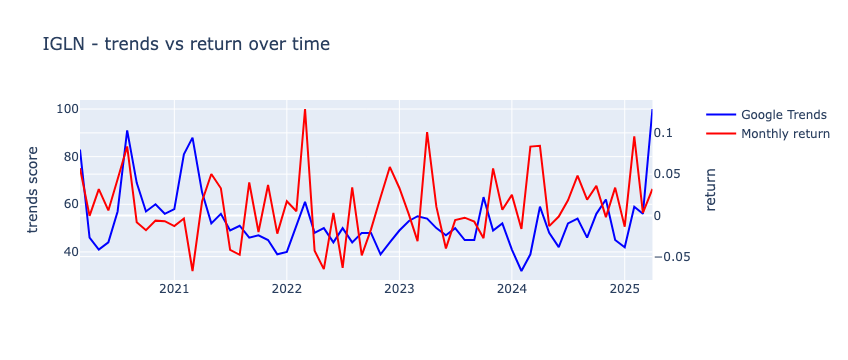

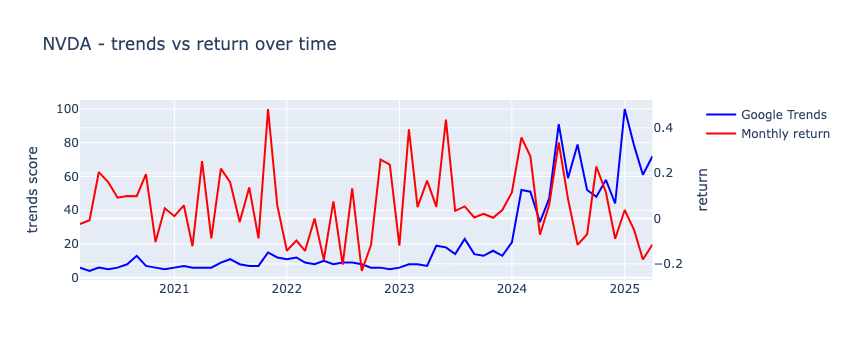

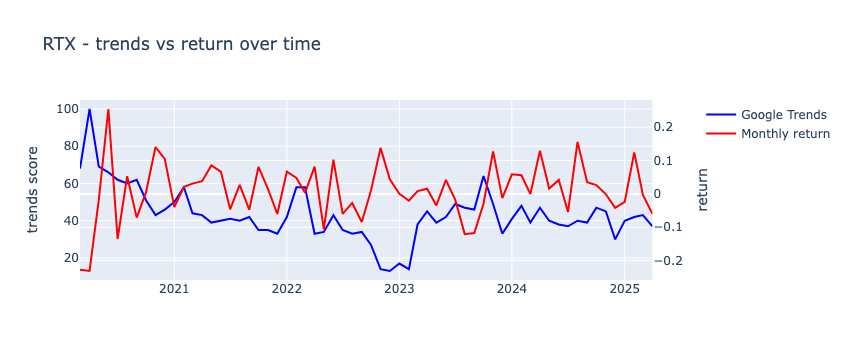

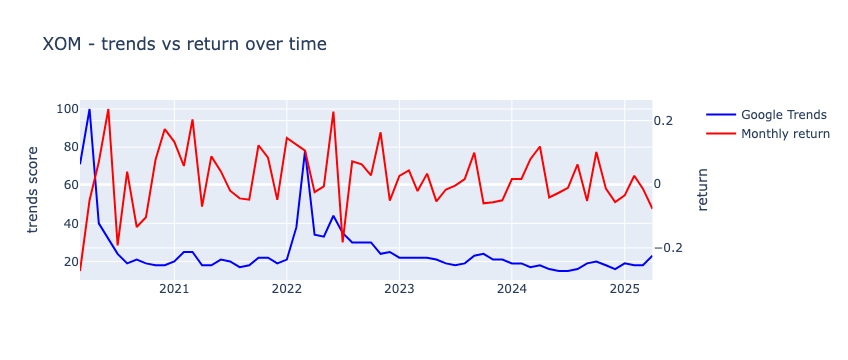

In [8]:
# plotting trends score vs monthly return for each asset
# using dual axis because the scales are very different

from plotly.subplots import make_subplots
import plotly.graph_objects as go

ASSETS = ['IGLN', 'NVDA', 'RTX', 'XOM']
RETURN_COLS = {
    'NVDA': 'NVDA_return',
    'RTX': 'RTX_return',
    'XOM': 'XOM_return',
    'IGLN': 'IGLN.L_return'
}
for asset in ASSETS:
    fig = make_subplots(specs=[[{'secondary_y': True}]])

    # trends score on left axis
    fig.add_trace(
        go.Scatter(x=df.index, y=df[f'{asset}_trends'],
                   name='Google Trends',
                   line=dict(color='blue')),
        secondary_y=False)

    # return on right axis
    ret_col = RETURN_COLS[asset]
    fig.add_trace(
        go.Scatter(x=df.index, y=df[ret_col],
                   name='Monthly return',
                   line=dict(color='red')),
        secondary_y=True)

    fig.update_layout(title=f'{asset} - trends vs return over time')
    fig.update_yaxes(title_text='trends score', secondary_y=False)
    fig.update_yaxes(title_text='return', secondary_y=True)
    
    fig.show()

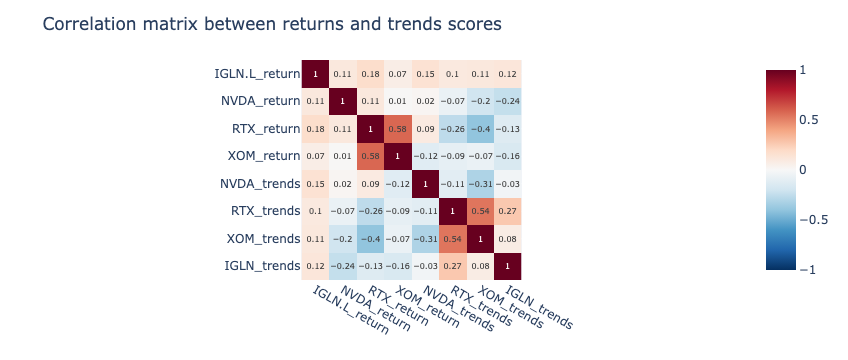

In [9]:
# correlation matrix to see how all variables relate to each other
import plotly.express as px

cols_i_want = ['IGLN.L_return', 'NVDA_return', 'RTX_return', 'XOM_return',
               'NVDA_trends', 'RTX_trends', 'XOM_trends', 'IGLN_trends']

corr_matrix = df[cols_i_want].corr()
corr_matrix = corr_matrix.round(2)

fig = px.imshow(corr_matrix,
                text_auto=True,
                color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1)

fig.update_layout(title='Correlation matrix between returns and trends scores')
fig.show()

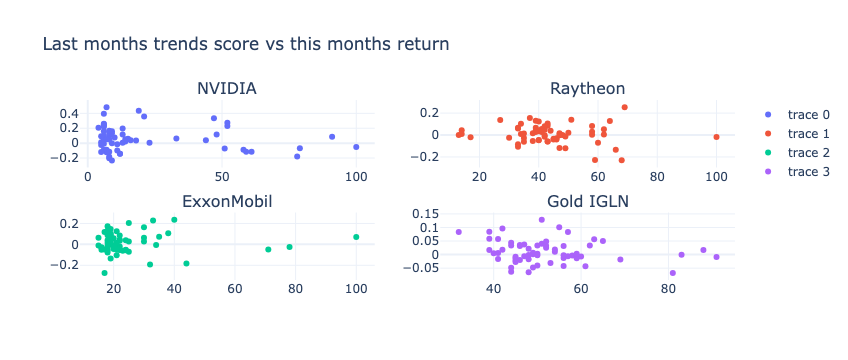

In [10]:
# scatter plots to see if last month's trends score predicts this month's return
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=['NVIDIA', 'Raytheon', 'ExxonMobil', 'Gold IGLN'])

# going through each asset manually
row_col = [(1,1), (1,2), (2,1), (2,2)]
assets_list = ['NVDA', 'RTX', 'XOM', 'IGLN']
return_list = ['NVDA_return', 'RTX_return', 'XOM_return', 'IGLN.L_return']

for i in range(4):
    asset = assets_list[i]
    ret = return_list[i]
    r = row_col[i][0]
    c = row_col[i][1]
    
    x_data = df[f'{asset}_trends_lag1']
    y_data = df[ret]
    
    fig.add_trace(
        go.Scatter(x=x_data, y=y_data, mode='markers'),
        row=r, col=c)

fig.update_layout(title='Last months trends score vs this months return',
                  template='plotly_white')
fig.show()

In [11]:
# cross correlation analysis
# I want to see if trends data comes before or after the returns
# positive lag = trends comes first, negative lag = returns come first

lags = list(range(-8, 9))
ccf_results = {}

for asset in ASSETS:
    correlations = []
    x = df[f'{asset}_trends'].values
    y = df[RETURN_COLS[asset]].values
    
    for lag in lags:
        if lag > 0:
            corr = np.corrcoef(x[:-lag], y[lag:])[0,1]
        elif lag < 0:
            corr = np.corrcoef(x[-lag:], y[:lag])[0,1]
        else:
            corr = np.corrcoef(x, y)[0,1]
        correlations.append(corr)
    
    ccf_results[asset] = dict(zip(lags, correlations))

# print the best lag for each asset
for asset in ASSETS:
    best_lag = max(ccf_results[asset], key=lambda l: abs(ccf_results[asset][l]))
    best_corr = ccf_results[asset][best_lag]
    if best_lag > 0:
        direction = 'LEADS'
    elif best_lag < 0:
        direction = 'LAGS'
    else:
        direction = 'CONCURRENT'
    print(f'{asset} → best lag: {best_lag} months, r = {round(best_corr, 3)}, Trends {direction} returns')

IGLN → best lag: -6 months, r = 0.243, Trends LAGS returns
NVDA → best lag: 2 months, r = -0.233, Trends LEADS returns
RTX → best lag: 8 months, r = 0.364, Trends LEADS returns
XOM → best lag: 8 months, r = 0.357, Trends LEADS returns


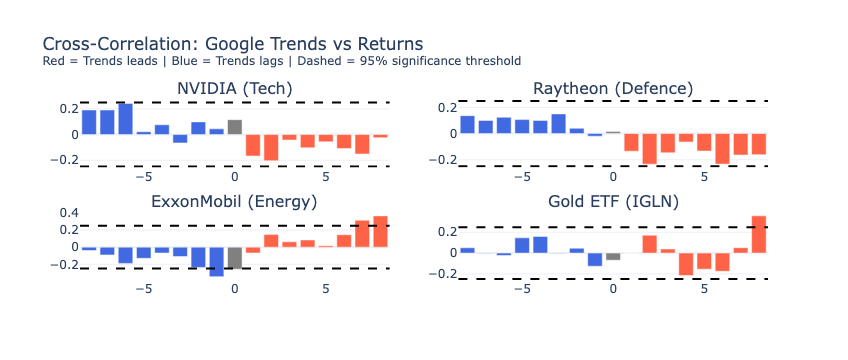

In [12]:
positions = [(1,1),(1,2),(2,1),(2,2)]

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=[f'NVIDIA (Tech)', 'Raytheon (Defence)',
                                    'ExxonMobil (Energy)', 'Gold ETF (IGLN)'])

for asset, (r, c) in zip(ASSETS, positions):
    lags  = list(ccf_results[asset].keys())
    corrs = list(ccf_results[asset].values())
    threshold = 1.96 / np.sqrt(len(df))
    colors = ['tomato' if l > 0 else 'royalblue' if l < 0 else 'grey' for l in lags]

    fig.add_trace(go.Bar(x=lags, y=corrs, marker_color=colors, showlegend=False), row=r, col=c)
    fig.add_hline(y=threshold,  line_dash='dash', line_color='black', row=r, col=c)
    fig.add_hline(y=-threshold, line_dash='dash', line_color='black', row=r, col=c)

fig.update_layout(
    title='Cross-Correlation: Google Trends vs Returns<br><sup>Red = Trends leads | Blue = Trends lags | Dashed = 95% significance threshold</sup>',
    template='plotly_white')
fig.show()

In [13]:
from statsmodels.tsa.stattools import grangercausalitytests

print(' Granger Causality Test: Does Google Trends predict returns? ')

for asset in ASSETS:
    data = df[[RETURN_COLS[asset], f'{asset}_trends']].dropna()
    results = grangercausalitytests(data, maxlag=4, verbose=False)
    for lag, res in results.items():
        f_stat = res[0]['ssr_ftest'][0]
        p_val  = res[0]['ssr_ftest'][1]
        sig    = '✓ Yes' if p_val < 0.05 else '✗ No'
        print(f'{asset:<12} {lag:<6} {f_stat:<12.3f} {p_val:<12.4f} {sig}')
    print()

 Granger Causality Test: Does Google Trends predict returns? 
IGLN         1      1.579        0.2140       ✗ No
IGLN         2      1.423        0.2497       ✗ No
IGLN         3      1.236        0.3060       ✗ No
IGLN         4      1.373        0.2571       ✗ No

NVDA         1      1.048        0.3102       ✗ No
NVDA         2      2.330        0.1068       ✗ No
NVDA         3      1.478        0.2313       ✗ No
NVDA         4      1.600        0.1892       ✗ No

RTX          1      0.265        0.6086       ✗ No
RTX          2      1.407        0.2534       ✗ No
RTX          3      0.255        0.8577       ✗ No
RTX          4      0.581        0.6776       ✗ No

XOM          1      0.001        0.9719       ✗ No
XOM          2      0.950        0.3929       ✗ No
XOM          3      0.587        0.6261       ✗ No
XOM          4      0.903        0.4695       ✗ No



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [14]:
# trying to predict next months return using last months trends score
# using a simple linear regression for each asset

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as stats

print('Linear Regression results:')

for asset in ASSETS:
    X = df[[f'{asset}_trends_lag1']].dropna()
    y = df.loc[X.index, RETURN_COLS[asset]]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    coef = model.coef_[0]

    slope, intercept, r_val, p_val, std_err = stats.linregress(
        X[f'{asset}_trends_lag1'], y)

    sig = '✓ Yes' if p_val < 0.05 else '✗ No'
    print(f'{asset:<12} {r2:<10.4f} {rmse:<12.4f} {coef:<14.6f} {p_val:<10.4f} {sig}')

Linear Regression results:
IGLN         -0.2042    0.0363       -0.000474      0.1564     ✗ No
NVDA         -4.3934    0.3339       0.004299       0.3222     ✗ No
RTX          -0.0727    0.0704       -0.000562      0.3837     ✗ No
XOM          -0.1561    0.0631       0.000007       0.8253     ✗ No


## Market Capitalisation Analysis

In this section we look at whether Google Trends search interest correlates with market capitalisation over time.

Note: IGLN is an ETF (Exchange Traded Fund) and does not have shares outstanding data like regular stocks, so this analysis only covers NVDA, RTX and XOM.

In [15]:
# getting market cap for each stock
# market cap = share price x number of shares
# note: IGLN is an ETF so no shares outstanding data available

nvda_stock = yf.Ticker('NVDA')
nvda_hist = nvda_stock.history(start='2020-01-01', end='2025-04-30', interval='1mo')
nvda_shares = nvda_stock.info.get('sharesOutstanding')
nvda_hist['NVDA_mcap'] = nvda_hist['Close'] * nvda_shares

rtx_stock = yf.Ticker('RTX')
rtx_hist = rtx_stock.history(start='2020-01-01', end='2025-04-30', interval='1mo')
rtx_shares = rtx_stock.info.get('sharesOutstanding')
rtx_hist['RTX_mcap'] = rtx_hist['Close'] * rtx_shares

xom_stock = yf.Ticker('XOM')
xom_hist = xom_stock.history(start='2020-01-01', end='2025-04-30', interval='1mo')
xom_shares = xom_stock.info.get('sharesOutstanding')
xom_hist['XOM_mcap'] = xom_hist['Close'] * xom_shares

# combine into one dataframe
mcap_df = pd.concat([nvda_hist[['NVDA_mcap']], rtx_hist[['RTX_mcap']], 
                     xom_hist[['XOM_mcap']]], axis=1)
mcap_df.index = pd.to_datetime(mcap_df.index).tz_localize(None)
mcap_df = mcap_df.resample('MS').first()

print(mcap_df.shape)
mcap_df.head()

(64, 3)


,NVDA_mcap,RTX_mcap,XOM_mcap
Date,,,
2020-01-01,1.425199e+11,1.095185e+11,1.922852e+11
2020-02-01,1.627981e+11,9.521988e+10,1.592265e+11
2020-03-01,1.589930e+11,6.910818e+10,1.192190e+11
2020-04-01,1.762916e+11,7.544763e+10,1.459075e+11
2020-05-01,2.141340e+11,7.511002e+10,1.427677e+11


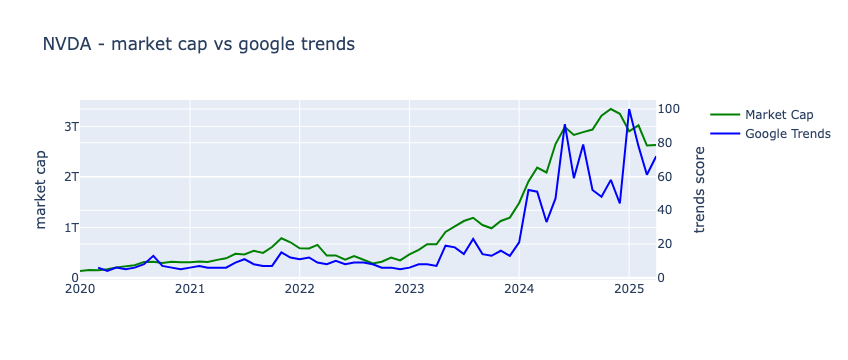

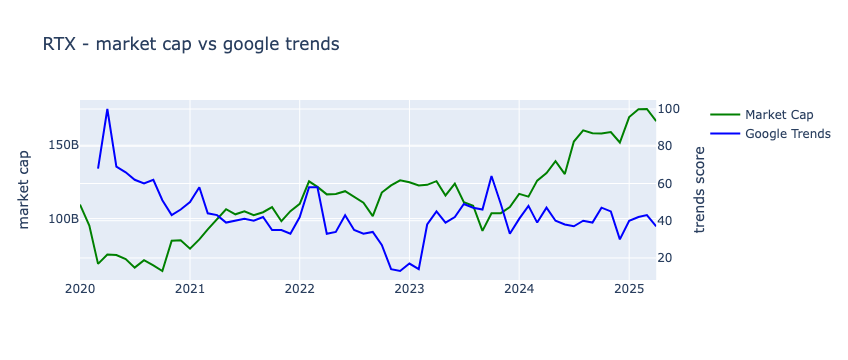

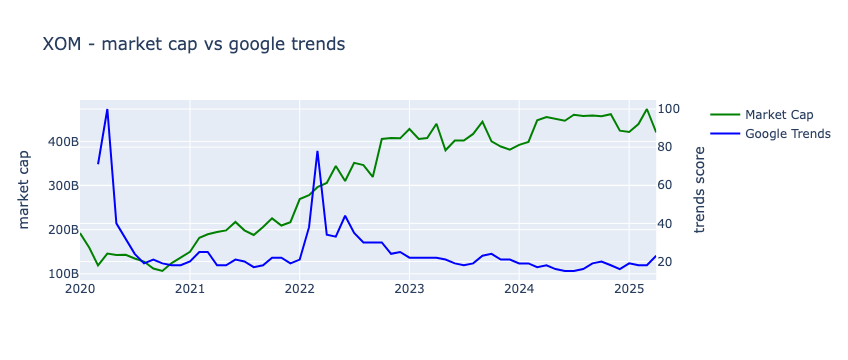

In [16]:
# plot market cap vs google trends for each stock
for asset in ['NVDA', 'RTX', 'XOM']:
    fig = make_subplots(specs=[[{'secondary_y': True}]])
    
    # market cap on left axis
    fig.add_trace(
        go.Scatter(x=mcap_df.index, y=mcap_df[f'{asset}_mcap'],
                   name='Market Cap',
                   line=dict(color='green')),
        secondary_y=False)
    
    # trends on right axis
    fig.add_trace(
        go.Scatter(x=df.index, y=df[f'{asset}_trends'],
                   name='Google Trends',
                   line=dict(color='blue')),
        secondary_y=True)
    
    fig.update_layout(title=f'{asset} - market cap vs google trends')
    fig.update_yaxes(title_text='market cap', secondary_y=False)
    fig.update_yaxes(title_text='trends score', secondary_y=True)
    fig.show()

In [17]:
# merge market cap with trends and check correlation
mcap_clean = mcap_df.copy()
mcap_clean.index = pd.to_datetime(mcap_clean.index)

# merge with trends
mcap_trends = mcap_clean.merge(trends_raw[['NVDA_trends', 'RTX_trends', 'XOM_trends']], 
                                left_index=True, right_index=True, how='inner')

# correlation between market cap and trends for each stock
print('Correlation between market cap and google trends:')
print('NVDA:', round(mcap_trends['NVDA_mcap'].corr(mcap_trends['NVDA_trends']), 3))
print('RTX:', round(mcap_trends['RTX_mcap'].corr(mcap_trends['RTX_trends']), 3))
print('XOM:', round(mcap_trends['XOM_mcap'].corr(mcap_trends['XOM_trends']), 3))

Correlation between market cap and google trends:
NVDA: 0.924
RTX: -0.46
XOM: -0.269


As we can see, we gathered 3 very different results. For Nvidia, we see a correlation of r = 0.924, which is extremely strong. This makes sense as Nvidia is one of the highest market capitalisations in the world, and became the face of the AI revolution from 2023 onwards, attracting massive media attention which explains the increase in search interest with its market cap growth.

Interestingly, RTX sits at -0.46, which suggests that defence stocks are more of an institutional investor territory, regular retail investors do not tend to research defence companies the same way they would a tech stock, even when the market cap grows.

Lastly, XOM shows a correlation of -0.269, which similarly suggests that energy is macro and news driven rather than retail attention driven. People do not Google ExxonMobil when oil prices rise, they just feel it at the gas station.

## Sentiment Analysis

To go a bit further, we decided to add a sentiment analysis layer to the project. The idea is simple: instead of just looking at how many people are searching for a stock, can we also measure whether the news around it is positive or negative?

To do this we used a model called FinBERT. We pulled recent headlines for each asset using NewsAPI and ran them through the model to get a score between -1 (very negative) and +1 (very positive).

The goal is to compare this sentiment signal with our Google Trends data and see if they resemble or contradict each other.

In [18]:
import requests

# using newsapi to get recent headlines for each stock
# free api key from newsapi.org
API_KEY = '1ed8e03d0d454807a51a2a79b5584d03'

# get headlines for nvidia
url_nvda = f'https://newsapi.org/v2/everything?q=Nvidia+stock&language=en&pageSize=20&apiKey={API_KEY}'
response_nvda = requests.get(url_nvda)
data_nvda = response_nvda.json()
headlines_nvda = [article['title'] for article in data_nvda['articles']]
print('NVDA:', len(headlines_nvda), 'headlines')

# get headlines for raytheon
url_rtx = f'https://newsapi.org/v2/everything?q=Raytheon+stock&language=en&pageSize=20&apiKey={API_KEY}'
response_rtx = requests.get(url_rtx)
data_rtx = response_rtx.json()
headlines_rtx = [article['title'] for article in data_rtx['articles']]
print('RTX:', len(headlines_rtx), 'headlines')

# get headlines for exxon
url_xom = f'https://newsapi.org/v2/everything?q=ExxonMobil+stock&language=en&pageSize=20&apiKey={API_KEY}'
response_xom = requests.get(url_xom)
data_xom = response_xom.json()
headlines_xom = [article['title'] for article in data_xom['articles']]
print('XOM:', len(headlines_xom), 'headlines')

# get headlines for gold
url_igln = f'https://newsapi.org/v2/everything?q=gold+price&language=en&pageSize=20&apiKey={API_KEY}'
response_igln = requests.get(url_igln)
data_igln = response_igln.json()
headlines_igln = [article['title'] for article in data_igln['articles']]
print('IGLN:', len(headlines_igln), 'headlines')

NVDA: 18 headlines
RTX: 12 headlines
XOM: 20 headlines
IGLN: 19 headlines


In [19]:
from transformers import pipeline

# load the finbert sentiment model
# this model was trained specifically on financial news
sentiment_model = pipeline('text-classification', model='ProsusAI/finbert')

# run sentiment on each asset's headlines
def get_sentiment_score(headlines):
    results = sentiment_model(headlines, truncation=True)
    scores = []
    for r in results:
        if r['label'] == 'positive':
            scores.append(r['score'])
        elif r['label'] == 'negative':
            scores.append(-r['score'])
        else:
            scores.append(0)
    return round(sum(scores) / len(scores), 3)

nvda_sentiment = get_sentiment_score(headlines_nvda)
rtx_sentiment = get_sentiment_score(headlines_rtx)
xom_sentiment = get_sentiment_score(headlines_xom)
igln_sentiment = get_sentiment_score(headlines_igln)

print('Average sentiment score (-1 = very negative, +1 = very positive):')
print('NVDA:', nvda_sentiment)
print('RTX:', rtx_sentiment)
print('XOM:', xom_sentiment)
print('IGLN:', igln_sentiment)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████| 201/201 [00:00<00:00, 52111.21it/s]


Average sentiment score (-1 = very negative, +1 = very positive):
NVDA: 0.026
RTX: 0.285
XOM: -0.012
IGLN: -0.06


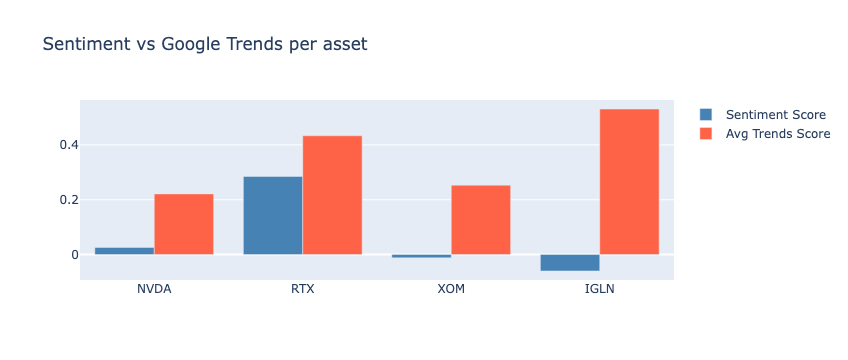

In [20]:
import plotly.graph_objects as go

# comparing sentiment vs average trends for each stock
assets = ['NVDA', 'RTX', 'XOM', 'IGLN']

sentiment_vals = [nvda_sentiment, rtx_sentiment, xom_sentiment, igln_sentiment]

avg_trends = [
    df['NVDA_trends'].mean() / 100,
    df['RTX_trends'].mean() / 100,
    df['XOM_trends'].mean() / 100,
    df['IGLN_trends'].mean() / 100
]

fig = go.Figure()
fig.add_trace(go.Bar(name='Sentiment Score', x=assets, y=sentiment_vals, marker_color='steelblue'))
fig.add_trace(go.Bar(name='Avg Trends Score', x=assets, y=avg_trends, marker_color='tomato'))

fig.update_layout(title='Sentiment vs Google Trends per asset', barmode='group')
fig.show()

As we can see on this graph, we get very different results across the four stocks.

For NVDA, we see negative sentiment but a high trends score, meaning people are actively searching for Nvidia even when the news around it is negative, which could reflect uncertainty or volatility rather than enthusiasm.

For RTX, both sentiment and trends are positive and relatively aligned, suggesting that news coverage and attention move in the same direction for defence stocks.

For XOM, sentiment is slightly negative with moderate search interest, which is consistent with what we found earlier: energy stocks are macro-driven and tend to fluctuate heavily with geopolitical events rather than retail attention.

Finally for IGLN, we see the highest trends score but negative sentiment, meaning people are searching for gold a lot, but the news around it remains negative.

## Conclusion

The goal of this project was to answer one question: does Google Trends search 
interest, fluctuate market movements across tech, defence, energy and gold?

The answer is that it depends on the sector. For RTX and XOM, search interest 
seems to lead returns by several months. For IGLN, it's the opposite, gold moves 
first and people search after. For NVDA the relationship was too varied to conclude 
anything clear, though we found a very strong correlation of 0.924 between its 
market cap and trends score, which makes sense given the AI media explosion since 2023.

The Granger causality and regression results were not statistically significant, 
which is likely due to having only 62 monthly data points. With weekly data we 
would have around 260 observations which would give much more reliable results.

The sentiment analysis added an interesting extra layer; for NVDA, people search 
a lot even when news is negative, while for RTX both signals are positive and 
aligned.

## Limitations and next steps

The main limitation is the sample size: monthly data over 5 years gives us very 
few observations for statistical tests. Using weekly Google Trends data and 
extending the time period would be the first improvement. Adding historical 
sentiment data rather than just recent headlines would also strengthen the analysis. 
An interesting extension would be building a live dashboard combining all three signals as 
a real portfolio monitoring tool.